In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore') 

In [21]:
333333333333333333333333333333333333333333

NumPy matrisleri yükleniyor, lütfen bekleyin...

--- ÖZELLİKLER (FEATURES) ---
Tip: <class 'numpy.ndarray'>
Boyut (Shape): (73492, 60, 24)

--- ETİKETLER (LABELS) ---
Tip: <class 'numpy.ndarray'>
Boyut (Shape): (73492,)
İlk 15 etiket:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Veri setindeki tüm farklı etiket sınıfları: [0. 1.]


In [3]:
# fake data

np.random.seed(42)

# 12 dakikada bir ölçülmüş 5000 satırlık zaman adımı
zaman_adimlari = pd.date_range(start="2024-01-01", periods=5000, freq="12min")

# 24 farklı manyetik alan özelliği
ozellikler = np.random.randn(5000, 24) 

# %90 Patlama Yok (0), %10 Patlama Var (1)
etiketler = np.random.choice([0, 1], size=5000, p=[0.9, 0.1])

In [4]:
df = pd.DataFrame(ozellikler, columns=[f"feature_{i}" for i in range(24)])
df['timestamp'] = zaman_adimlari
df['label'] = etiketler

In [7]:
# clean data
print("Orijinal Veri Boyutu:", df.shape)

# Zaman sütununu indeks yap (Zaman serisi analizinin altın kuralı)
if 'timestamp' in df.columns:
    df.set_index('timestamp', inplace=True)

# Eksik Verileri Doldurma (Zaman sızıntısı yapmadan ileriye doğru)
df.ffill(inplace=True) # Önceki geçerli değerle doldur
df.bfill(inplace=True) # En başta boşluk varsa sonrakiyle doldur

print("Temizlik tamamlandı. Eksik veri sayısı:", df.isna().sum().sum())

Orijinal Veri Boyutu: (5000, 25)
Temizlik tamamlandı. Eksik veri sayısı: 0


In [9]:
# split data

# Toplam satır sayısını alalım
toplam_satir = len(df)

# %70 Train, %15 Validation oranlarının indeks sınırlarını bulalım
train_sinir = int(toplam_satir * 0.70)
val_sinir = int(toplam_satir * 0.85)

# Veriyi BÖL (Zaman sırasını bozmadan)
train_df = df.iloc[:train_sinir].copy()
val_df = df.iloc[train_sinir:val_sinir].copy()
test_df = df.iloc[val_sinir:].copy()

# Etiketleri (y) ve Özellikleri (X) ayıralım
y_train = train_df.pop('label')
X_train = train_df

y_val = val_df.pop('label')
X_val = val_df

y_test = test_df.pop('label')
X_test = test_df

print(f"Train Seti (Eğitim): {X_train.shape}")
print(f"Validation Seti (Doğrulama): {X_val.shape}")
print(f"Test Seti (Son Sınav): {X_test.shape}")

Train Seti (Eğitim): (3500, 24)
Validation Seti (Doğrulama): (750, 24)
Test Seti (Son Sınav): (750, 24)


In [11]:
# scale data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaler SADECE Train verisinden öğrenir (fit) ve dönüştürür (transform)
X_train_scaled = scaler.fit_transform(X_train)

# Val ve Test verilerine SADECE dönüştürme (transform) uygulanır. 
# DİKKAT: Burada 'fit' kullanmıyoruz! Veri sızıntısını böyle engelliyoruz.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklendirme başarıyla tamamlandı, gelecekten kopya çekilmedi!")

Ölçeklendirme başarıyla tamamlandı, gelecekten kopya çekilmedi!


In [13]:
# create sequences

# Hücre 5: Dizileri Oluşturma ve Tensör Dönüşümü
import torch

def create_sequences(X_scaled, y_labels, time_steps):
    """Veriyi time_steps uzunluğunda pencerelere böler."""
    Xs, ys = [], []
    for i in range(len(X_scaled) - time_steps):
        # time_steps kadar satırı al (Örn: 50 satır = 10 saat)
        Xs.append(X_scaled[i : (i + time_steps)])
        # Pencerenin bittiği yerin bir adım sonrasındaki hedefi al
        ys.append(y_labels.iloc[i + time_steps])
        
    return np.array(Xs), np.array(ys)

TIME_STEPS = 50 # Modale "son 50 adımı (10 saati) incele" diyoruz.

# NumPy Matrislerini Oluştur
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, TIME_STEPS)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, TIME_STEPS)

# PyTorch Tensörlerine Dönüştür
# PyTorch, ondalıklı sayılar için float32 formatını sever
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
# Etiketleri (N, 1) boyutuna getiriyoruz ki kayıp fonksiyonunda hata çıkmasın (unsqueeze)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32).unsqueeze(1) 

X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_t = torch.tensor(y_val_seq, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32).unsqueeze(1)

print(f"PyTorch Train Giriş Tensörü (X): {X_train_t.shape}")
print(f"PyTorch Train Hedef Tensörü (y): {y_train_t.shape}")

PyTorch Train Giriş Tensörü (X): torch.Size([3450, 50, 24])
PyTorch Train Hedef Tensörü (y): torch.Size([3450, 1])


In [14]:
# attention class_weights LSTM

# PyTorch LSTM + Attention Mimarisi
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        # Dikkat skorlarını hesaplamak için basit bir lineer katman
        self.attention = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out boyutu: (batch_size, time_steps, hidden_dim)
        
        # Her zaman adımı için bir skor hesapla
        attn_scores = self.attention(lstm_out) # Boyut: (batch_size, time_steps, 1)
        
        # Skorları 0-1 arası olasılıklara (ağırlıklara) çevir
        attn_weights = F.softmax(attn_scores, dim=1) 
        
        # LSTM çıktılarını bu dikkat ağırlıklarıyla çarp ve topla (Context Vector)
        # Hangi zaman adımının ağırlığı yüksekse, model o anki veriye daha çok odaklanır
        context_vector = torch.sum(attn_weights * lstm_out, dim=1) # Boyut: (batch_size, hidden_dim)
        
        return context_vector, attn_weights

class SolarFlarePredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout_rate=0.3):
        super(SolarFlarePredictor, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM Katmanı
        # batch_first=True çok önemli! Çünkü tensörlerimiz (Batch, Time, Features) sırasında
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, 
                            dropout=dropout_rate if num_layers > 1 else 0)
        
        # Attention Katmanımız
        self.attention = Attention(hidden_dim)
        
        # Tam Bağlı (Dense/Linear) Katmanlar
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        
        # Çıktı katmanı: Sadece 1 nöron (Patlama olacak mı, olmayacak mı?)
        self.fc2 = nn.Linear(32, 1) 
        self.sigmoid = nn.Sigmoid() # Çıktıyı 0 ile 1 arasına (olasılığa) sıkıştırır
        
    def forward(self, x):
        # x'in boyutu: (batch_size, time_steps, input_dim)
        
        # Veriyi LSTM'den geçiriyoruz
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # LSTM çıktılarını Attention mekanizmasına veriyoruz
        context_vector, attn_weights = self.attention(lstm_out)
        
        # Dikkatlice seçilmiş bilgiyi sinir ağına sokuyoruz
        out = self.fc1(context_vector)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        # Sonuç: 0 ile 1 arası olasılık
        olasilik = self.sigmoid(out)
        
        return olasilik, attn_weights

# --- MODELİ BAŞLATMA VE TEST ETME ---

# Hiperparametreler
INPUT_DIM = 24       # Veri setimizdeki özellik sayısı (örneğin manyetik akı, alan vb.)
HIDDEN_DIM = 64      # LSTM'in içindeki hafıza hücresi sayısı
NUM_LAYERS = 2       # Üst üste 2 LSTM katmanı

# Modeli yarat
model = SolarFlarePredictor(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
print(model)

SolarFlarePredictor(
  (lstm): LSTM(24, 64, num_layers=2, batch_first=True, dropout=0.3)
  (attention): Attention(
    (attention): Linear(in_features=64, out_features=1, bias=False)
  )
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [15]:
# Data loader optimizer loss

# DataLoader, Loss ve Optimizer Kurulumu
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

# DataLoader Hazırlığı
BATCH_SIZE = 64

# Tensörleri birleştirip paketlenebilir hale getiriyoruz
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Eğitim verisi karıştırılır (shuffle=True), Val ve Test karıştırılmaz!
# Not: Pencereleri (sequences) oluşturduğumuz için artık karıştırmak zaman akışını bozmaz, 
# çünkü her bir pencerenin içi zaten kendi kronolojisine sahip.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sınıf Dengesizliği İçin Pozitif Ağırlık (pos_weight) Hesaplama
# pos_weight = (Patlama Olmayanların Sayısı) / (Patlama Olanların Sayısı)
# Bu oran sayesinde model bir patlamayı kaçırdığında çok daha büyük ceza alacak.
negatif_sayisi = (y_train_seq == 0).sum()
pozitif_sayisi = (y_train_seq == 1).sum()
pozitif_agirlik = torch.tensor([negatif_sayisi / pozitif_sayisi], dtype=torch.float32)

print(f"Patlama anlarına verilecek ceza katsayısı (pos_weight): {pozitif_agirlik.item():.2f}")

# Kayıp Fonksiyonu (Binary Cross Entropy)
# Modelimizde zaten Sigmoid olduğu için BCELoss kullanıyoruz ve ağırlığımızı veriyoruz.
criterion = nn.BCELoss(weight=None) # Standart tanımlama

# Not: Özel durumlarda PyTorch'ta 'pos_weight' parametresi BCEWithLogitsLoss ile kullanılır.
# Ama biz ağırlığı manuel olarak eğitim döngüsü içinde loss değerine çarpacağız 
# ki kontrol tamamen bizde olsun.

# Optimizatör
# Öğrenme oranını (learning_rate) 0.001 olarak belirliyoruz
optimizer = optim.Adam(model.parameters(), lr=0.001)

Patlama anlarına verilecek ceza katsayısı (pos_weight): 8.27


In [16]:
# Train

# Eğitim Döngüsü (Training Loop)
EPOCHS = 15 # Model tüm veri setini kaç kere görecek?

print("Eğitim başlıyor...")

for epoch in range(EPOCHS):
    model.train() # Modeli eğitim moduna al (Dropout vb. aktif olur)
    toplam_train_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Gradyanları sıfırla (PyTorch geçmiş adımları hafızada tutar, bunu temizlemeliyiz)
        optimizer.zero_grad()
        
        # İleri Yayılım (Tahmin yap)
        # Model bize tahmini ve attention ağırlıklarını döndürüyor
        tahminler, _ = model(batch_X) 
        
        # Hatayı (Loss) Hesapla
        loss = criterion(tahminler, batch_y)
        
        # Dengesizlik için ağırlığı manuel uyguluyoruz: 
        # Eğer gerçek etiket 1 (Patlama) ise hatayı pozitif_agirlik ile çarpıyoruz
        agirlikli_loss = loss * torch.where(batch_y == 1, pozitif_agirlik, torch.tensor(1.0))
        ortalama_loss = agirlikli_loss.mean()
        
        # Geri Yayılım (Backpropagation) - Hataları ağa dağıt
        ortalama_loss.backward()
        
        # Ağırlıkları Güncelle
        optimizer.step()
        
        toplam_train_loss += ortalama_loss.item()
        
    # --- Validation (Doğrulama) Aşaması ---
    # Her epoch sonunda modelin görmediği Val verisindeki başarısına bakıyoruz
    model.eval() # Modeli test moduna al
    toplam_val_loss = 0
    
    with torch.no_grad(): # Test sırasında gradyan hesaplama (RAM tasarrufu)
        for val_X, val_y in val_loader:
            val_tahminler, _ = model(val_X)
            v_loss = criterion(val_tahminler, val_y)
            toplam_val_loss += v_loss.item()
            
    # Ortalama kayıpları yazdır
    avg_train_loss = toplam_train_loss / len(train_loader)
    avg_val_loss = toplam_val_loss / len(val_loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

Eğitim başlıyor...
Epoch 1/15 | Train Loss: 0.8380 | Validation Loss: 0.3117
Epoch 2/15 | Train Loss: 0.6487 | Validation Loss: 0.3154
Epoch 3/15 | Train Loss: 0.6478 | Validation Loss: 0.3122
Epoch 4/15 | Train Loss: 0.6423 | Validation Loss: 0.3148
Epoch 5/15 | Train Loss: 0.6458 | Validation Loss: 0.3114
Epoch 6/15 | Train Loss: 0.6527 | Validation Loss: 0.3231
Epoch 7/15 | Train Loss: 0.6449 | Validation Loss: 0.3197
Epoch 8/15 | Train Loss: 0.6425 | Validation Loss: 0.3119
Epoch 9/15 | Train Loss: 0.6433 | Validation Loss: 0.3217
Epoch 10/15 | Train Loss: 0.6312 | Validation Loss: 0.3551
Epoch 11/15 | Train Loss: 0.6460 | Validation Loss: 0.3192
Epoch 12/15 | Train Loss: 0.6133 | Validation Loss: 0.3346
Epoch 13/15 | Train Loss: 0.6147 | Validation Loss: 0.3492
Epoch 14/15 | Train Loss: 0.6143 | Validation Loss: 0.3360
Epoch 15/15 | Train Loss: 0.5949 | Validation Loss: 0.3264


Test aşaması başlıyor...

--- TEST SETİ SONUÇLARI ---
Accuracy (Doğruluk):  0.9000 (Buna çok güvenme!)
Precision (Kesinlik): 0.2500 (Patlama dediklerinin yüzde kaçı gerçekten patladı?)
Recall (Duyarlılık):  0.0147 (Gerçek patlamaların yüzde kaçını yakalayabildik?)
F1-Score:             0.0278 (Kesinlik ve Duyarlılığın harmonik ortalaması)


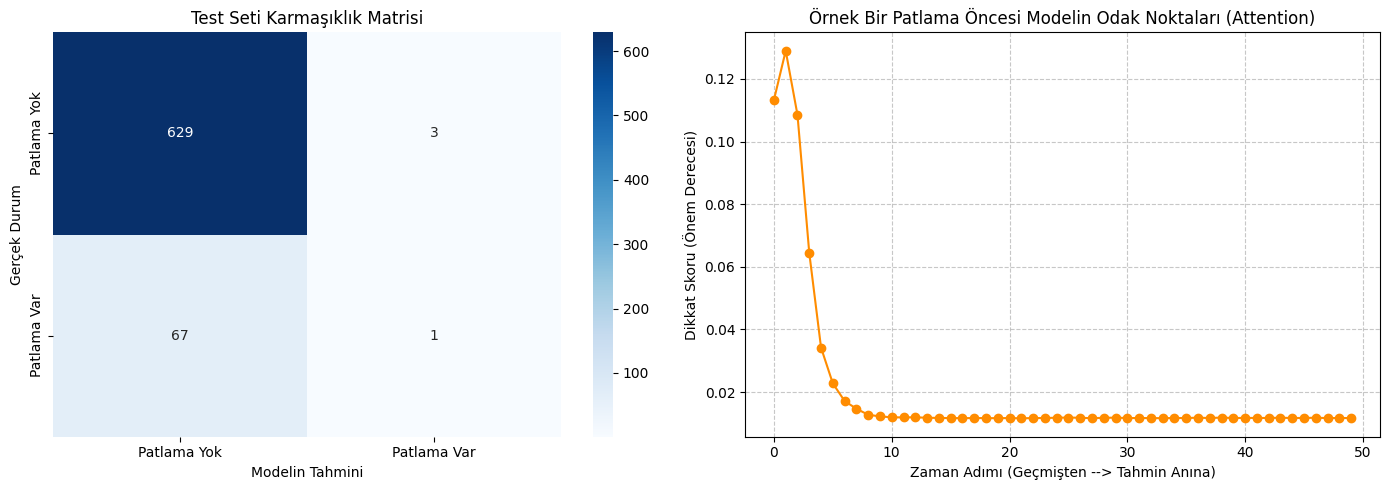

In [17]:
# Hücre 9: Test, Değerlendirme ve Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Test aşaması başlıyor...")

model.eval() # Modeli değerlendirme moduna al (Dropout kapanır)
test_tahminleri = []
test_gercekleri = []
ornek_attention_agirliklari = None

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        tahmin_olasiliklari, attn_weights = model(batch_X)
        
        # 0.5'ten büyük olasılıkları 1 (Patlama Var), küçükleri 0 (Patlama Yok) kabul et
        tahmin_siniflari = (tahmin_olasiliklari >= 0.5).float()
        
        test_tahminleri.extend(tahmin_siniflari.numpy())
        test_gercekleri.extend(batch_y.numpy())
        
        # Görselleştirme için son batch'in ilk örneğinin attention ağırlıklarını sakla
        if ornek_attention_agirliklari is None:
            ornek_attention_agirliklari = attn_weights[0].numpy()

# 1. Metrikleri Hesapla
acc = accuracy_score(test_gercekleri, test_tahminleri)
prec = precision_score(test_gercekleri, test_tahminleri, zero_division=0)
rec = recall_score(test_gercekleri, test_tahminleri, zero_division=0)
f1 = f1_score(test_gercekleri, test_tahminleri, zero_division=0)

print("\n--- TEST SETİ SONUÇLARI ---")
print(f"Accuracy (Doğruluk):  {acc:.4f} (Buna çok güvenme!)")
print(f"Precision (Kesinlik): {prec:.4f} (Patlama dediklerinin yüzde kaçı gerçekten patladı?)")
print(f"Recall (Duyarlılık):  {rec:.4f} (Gerçek patlamaların yüzde kaçını yakalayabildik?)")
print(f"F1-Score:             {f1:.4f} (Kesinlik ve Duyarlılığın harmonik ortalaması)")

# 2. Görselleştirme (Karmaşıklık Matrisi)
cm = confusion_matrix(test_gercekleri, test_tahminleri)

plt.figure(figsize=(14, 5))

# Sol Grafik: Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Patlama Yok', 'Patlama Var'], 
            yticklabels=['Patlama Yok', 'Patlama Var'])
plt.title('Test Seti Karmaşıklık Matrisi')
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')

# Sağ Grafik: Attention Ağırlıkları
# Model, 50 zaman adımının (10 saatin) hangi anlarına daha çok dikkat etmiş?
plt.subplot(1, 2, 2)
plt.plot(ornek_attention_agirliklari, marker='o', color='darkorange')
plt.title('Örnek Bir Patlama Öncesi Modelin Odak Noktaları (Attention)')
plt.xlabel('Zaman Adımı (Geçmişten --> Tahmin Anına)')
plt.ylabel('Dikkat Skoru (Önem Derecesi)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [18]:
# Hücre 10: Modeli ve Scaler'ı Kaydetme
import torch
import joblib # Scaler'ı kaydetmek için

# 1. Model Ağırlıklarını Kaydet
model_yolu = 'solar_flare_lstm_attention.pth'
torch.save(model.state_dict(), model_yolu)
print(f"Model başarıyla '{model_yolu}' adıyla kaydedildi.")

# 2. Scaler'ı Kaydet (Çok Önemli!)
# Canlı sistemde yeni bir veri geldiğinde, modeli eğitirken kullandığımız 
# aynı oranlarla ölçeklendirmemiz gerekir. Bu yüzden scaler da kaydedilmeli.
scaler_yolu = 'solar_flare_scaler.pkl'
joblib.dump(scaler, scaler_yolu)
print(f"Ölçeklendirici (Scaler) başarıyla '{scaler_yolu}' adıyla kaydedildi.")

# İstediğin zaman geri yüklemek için:
# yuklenen_model = SolarFlarePredictor(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS)
# yuklenen_model.load_state_dict(torch.load('solar_flare_lstm_attention.pth'))
# yuklenen_scaler = joblib.load('solar_flare_scaler.pkl')

Model başarıyla 'solar_flare_lstm_attention.pth' adıyla kaydedildi.
Ölçeklendirici (Scaler) başarıyla 'solar_flare_scaler.pkl' adıyla kaydedildi.
